In [ ]:
import numpy as np
import cv2
import json
import csv
import pathlib
from pathlib import Path
import os
import re
import pickle
import scipy.spatial.transform
import matplotlib.pyplot as plt


complete_corner_mapping = {
    "AB": ["A","B","D","C"],
    "BC": ["B","C","A","D"],
    "CD": ["C","D","B","A"],
    "DA": ["D","A","C","B"],
    "AD": ["A","D","B","C"],
    "DC": ["D","C","A","B"],
    "CB": ["C","B","D","A"],
    "BA": ["B","A","C","D"]
}

clockwise_rotation = ["AB","BC","CD","DA"]

default_corner_order = "BC"

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.0001)

# Calibration of N Cameras

**Note**: This calibration procedure requires
- A rectangular checkerboard with one recognizable side:
    ```
    A             B
      |-|-|-|-|-|
      | | | | | |
      | | | | | |
    D |-|-|-|-|-| C
      visual clue
    ```
- A manually created file `video_2_frame_number.json` which annotates for each video the frame-sequences during which the checkerboard is visible in this video:
    ```json
    {
        "cam-2": {
        "sequences": [
            [129, 344],
            [1777, 2876]
        ],
        "best_sequences_idx": [1]
        },
        "cam-3": {
            "sequences": [
                [330, 657], 
                [1355, 1552], 
                [1775, 2372], 
                [4031, 4272]
            ],
            "best_sequences_idx": [2,3] 
        },
        ...
    }
    ```
- A manually created file `filename_2_upper_side.json` which annotates during which frame-sequences which side of the checkerboard points upwards:
    ```json
    {
        "video_0.mp4": [
            {
                "start": 0,
                "end": 132,
                "upside": "BC"
            },
            ...
        ],
        ...
    }
    ```
    The specified sequences also determine which frames are gonna be used for calibration.


## Utility

In [ ]:
def dict_from_dict_or_json_file(file_or_dict):
    if type(file_or_dict) is dict:
        return file_or_dict
    else: 
        with open(file_or_dict) as jf:
            file_content = json.load(jf)
        return file_content

In [ ]:
def draw_camera(ax, C, R, color='blue', label='Camera', scale=50):
    """Draw a camera frustum at center C with rotation R."""
    w, h = 0.4, 0.3
    img_plane = np.array([
        [ w,  h, 1],
        [-w,  h, 1],
        [-w, -h, 1],
        [ w, -h, 1]
    ]) * scale

    frustum_pts = (R @ img_plane.T).T + C

    for pt in frustum_pts:
        ax.plot([C[0], pt[0]], [C[1], pt[1]], [C[2], pt[2]], color=color)

    idx = [0, 1, 2, 3, 0]
    ax.plot(frustum_pts[idx, 0], frustum_pts[idx, 1], frustum_pts[idx, 2], color=color, label=label)


def draw_corners_with_order(image, corners, view="side"):
    """Custom drawing function for detected chessboard corners."""
    corners = corners.reshape(-1, 2)  # Flatten the corners for easier indexing

    # Copy the image to draw on
    image_copy = image.copy()

    # Define font, color, and scale for drawing text
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5
    color = (0, 0, 255)  # Red color for the text
    thickness = 1

    # Draw the corner points with their order number
    for i, corner in enumerate(corners):
        corner_position = tuple(corner.astype(int))
        cv2.circle(
            image_copy, corner_position, 5, (0, 255, 0), -1
        )  # Draw a small circle at the corner
        cv2.putText(
            image_copy,
            str(i + 1),
            corner_position,
            font,
            font_scale,
            color,
            thickness,
            cv2.LINE_AA,
        )

    return image_copy

In [ ]:
def enhance_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    # enhanced = cv2.equalizeHist(gray)
    # enhanced = cv2.GaussianBlur(enhanced, (5, 5), 0)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # Sharpening
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    enhanced = cv2.filter2D(gray, -1, kernel)
    return enhanced

In [ ]:
def extract_from_video(
    videos: list[Path],
    video_2_frame_number,
    out_dir: Path,
):
    video_2_frame_number = dict_from_dict_or_json_file(video_2_frame_number)
    out_dir.mkdir(exist_ok=True)

    json_out_path = out_dir / "index.json"
    json_index = {"frame_folders": [], "index_files": {}, "image_sizes": {}}

    for video_path in videos:
        if not video_path.exists():
            raise Exception(f"Input video does not exist: {video_path}")

        print(f"processing video: {video_path}")

        # read one frame to get vheight and vwidth
        capture = cv2.VideoCapture(str(video_path))
        try:
            if not capture.isOpened():
                raise ValueError(f"couldn't open video: {video_path}")
            success, frame = capture.read()
            if not success:
                raise ValueError(f"video {video_path} couldn't be read.")
            vheight, vwidth = frame.shape[:2]
        finally:
            capture.release()

        video_name = video_path.stem

        video_folder = out_dir / video_name
        raw_imgs_dir = video_folder / "raw_imgs"
        raw_imgs_dir.mkdir(parents=True, exist_ok=True)

        files_csv_path = video_folder / "files.csv"
        with files_csv_path.open("w", newline="") as csv_out_file:
            csvwriter = csv.writer(
                csv_out_file, delimiter=",", quotechar='"', quoting=csv.QUOTE_MINIMAL
            )
            csvwriter.writerow(["frame", "file_loc", "stereo_partner", "video"])

            capture = cv2.VideoCapture(str(video_path))

            image_count = 0
            frame_number = 0
            success = True

            try:
                if not capture.isOpened():
                    raise ValueError(f"couldn't open video: {video_path}")
                while capture.isOpened() and success:
                    success, frame = capture.read()
                    if not success:
                        break
                
                    if any(
                        [frame_number >= sequence[0] and frame_number <= sequence[1]] 
                        for sequence in video_2_frame_number[video_name]["sequences"]
                    ):
                        filename = f"{video_name}_{frame_number}.png"
                        abs_file_path = raw_imgs_dir / filename

                        cv2.imwrite(str(abs_file_path), frame)

                        stereo_partners = []

                        for v in video_2_frame_number:
                            if v == video_name:
                                continue
                            if any(
                                [frame_number >= sequence[0] and frame_number <= sequence[1]] 
                                for sequence in video_2_frame_number[v]["sequences"]
                            ):
                                stereo_partners.append(v)
                        csvwriter.writerow(
                            [frame_number, abs_file_path, stereo_partners, video_name]
                        )
                        image_count += 1

                        print(
                            f"frame out: {frame_number}, total image count: {image_count}",
                            end="\r",
                        )
                    
                    frame_number += 1

                print(f"total image: {image_count}, done")

                json_index["frame_folders"].append(video_name)
                json_index["index_files"][video_name] = str(files_csv_path)
                json_index["image_sizes"][video_name] = [int(vwidth), int(vheight)]
            finally:
                capture.release()

    json_index["image_count"] = image_count

    with json_out_path.open("w") as f:
        json.dump(json_index, f, indent=2)

In [ ]:
"""
Identify the upwards facing side based on two criteria:
    1) It has to include the top-most corner
    2) It has to be close to horizontal
"""
def identify_upwards_facing_edge(key_corners):
    neighbours_by_index = {
        0: [key_corners[1],key_corners[2]],
        1: [key_corners[0],key_corners[3]],
        2: [key_corners[0],key_corners[3]],
        3: [key_corners[1],key_corners[2]]
    }

    # Sort by Y coordinate
    sorted_by_y = sorted(key_corners, key=lambda p: p[1])[::-1] # opencv y-coordinates are inverted
    top_most = sorted_by_y[2:4]  # Two highest corners
    top_most_corner = top_most[1]
    top_most_index = next(i for i, c in enumerate(key_corners) if np.array_equal(c, top_most_corner))

    # each edge that includes the top-most corner is a candidate for the upwards-facing side.
    facing_up_candidates = []
    if top_most[1][1] != top_most[0][1]: # if there is exactly one top most corner, i.e. the upper side is not horizontal:
        for neighbour in neighbours_by_index[top_most_index]:
            facing_up_candidates.append((top_most_corner, neighbour))
    else: # in the unlikely case that the top two corners share their y-coordinate
        facing_up_candidates.append((top_most[1], top_most[0]))
    
    def compute_angle(p1, p2):
        return np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))

    minDeviation = 90  # Start with the worst possible case
    facing_up = None
    for candidate in facing_up_candidates:
        angle = compute_angle(*candidate)
        deviation = min(abs(angle), abs(180 - abs(angle)))  # Ensure we measure closeness to horizontal
        if deviation < minDeviation:
            facing_up = candidate
            minDeviation = deviation

    return facing_up


"""
The (arbitrarily chosen) corner-naming for the checkerboard looks like this:
A         B
  |-|-|-|
  | | | |
  | | | |
D |-|-|-| C
  loopbio

Based on coordinates of the imagepoints and based on a user-given ground-truth about positions of corners in the image, 
a correspondence between the above real-world corners and imgpoints is recovered.
"""
def detect_corner_order(imgpoints, cbwidth, cbheight, upwards_facing_side):
    # Extract four key corners
    first = imgpoints[0]
    second = imgpoints[cbheight - 1]
    third = imgpoints[cbheight * cbwidth - cbheight]
    forth = imgpoints[cbheight * cbwidth - 1]
    key_corners = np.array([first, second, third, forth])
    
    facing_up = identify_upwards_facing_edge(key_corners)
    facing_up_left  = facing_up[0] if facing_up[0][0] < facing_up[1][0] else facing_up[1]
    facing_up_right = facing_up[0] if facing_up[0][0] > facing_up[1][0] else facing_up[1]
    
    # Now, we have a correspondence between the key-corners and real-world chessboard points
    # Identify the corresponding index
    index_of_facing_up_left_end = next(
        i for i, c in enumerate(key_corners) if np.all(np.isclose(c, facing_up_left))
    )
    index_of_facing_up_right_end = next(
        i for i, c in enumerate(key_corners) if np.all(np.isclose(c, facing_up_right))
    )

    print(f"facing up left corner index: {index_of_facing_up_left_end} ({facing_up_left})\nfacing up right corner index: {index_of_facing_up_right_end} ({facing_up_right})\n")

    # Find out which of the 8 corner orders is the order of the currently detected imagepoints based on where in the order the upwards pointing corners are:
    corner_order = None
    for short, order in complete_corner_mapping.items():
        if order[index_of_facing_up_left_end] == upwards_facing_side[0] and order[index_of_facing_up_right_end] == upwards_facing_side[1]:
            corner_order = short
            
    return corner_order
    

"""
A matrix rotation of 90 degree is a transpose with reordering.
Elements that were in a row have to be into a column after rotation, hence transpose.
If we then reverse the order within the rows (i.e. we push around columns) we get each former row (now column) to it's desired rotated position.
"""
def rotate_90_clockwise(m, iterations=1):
    for i in range(iterations):
        m = np.flip(m.transpose([1,0,2]), 0)
    return m

In [ ]:
def reorder_corners(imgpoints_input, upwards_facing_side_input, cbrows, cbcols):
    objpoints = {}
    
    filename_to_upside = dict_from_dict_or_json_file(upwards_facing_side_input)

    def find_ground_truth_upside(num):
        for entry in filename_to_upside:
            if entry["start"] <= num <= entry["end"]:
                return entry["upside"]
        return None

    imgpoints = dict_from_dict_or_json_file(imgpoints_input)

    # prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
    objp = np.zeros((cbrows*cbcols,3), np.float32)
    objp[:,:2] = np.mgrid[0:cbrows,0:cbcols].T.reshape(-1,2)
    
    imgpoints = {imgname:np.array(imgpoints[imgname]) for imgname in sorted(imgpoints.keys())}

    for imgname, points in imgpoints.items(): 
        print(f"{imgname}: [{points[0]}, ...]")
    for i, (imgname, points) in enumerate(imgpoints.items()):
        print(f"\n\n{imgname}\n")
        imgnum = int(imgname)
        ground_truth_upside = find_ground_truth_upside(imgnum)
        print(f"ground truth upside: {ground_truth_upside}\n")
        if ground_truth_upside is None:
            continue
        this_corner_order = detect_corner_order(points, cbheight=cbrows, cbwidth=cbcols, upwards_facing_side=ground_truth_upside)
        imgpt2 = np.copy(points).reshape(cbrows,cbcols,2)
        print(f"corner order before: {this_corner_order}\n")
        if this_corner_order is not None: 
            """ 
            if counter-clockwise corner-assignment: reverse rows 
            """
            if this_corner_order not in clockwise_rotation: 
                imgpt2 = np.flip(imgpt2, 1)
                this_corner_order = this_corner_order[::-1]
                print(f"corner order clockwise: {this_corner_order}\n")
            """ 
            rotate imgpoints matrix so that every detected point corresponds to the correct point in each other image 
            """
            while this_corner_order != default_corner_order:
                index = clockwise_rotation.index(this_corner_order)
                imgpt2 = rotate_90_clockwise(imgpt2, iterations=1)
                #print(f"{objp2[0]}\n{objp2[1]}\n ... ... ")
                index = (index-1) % len(clockwise_rotation)
                this_corner_order = clockwise_rotation[index]
                print(f"corner order rotated: {this_corner_order}\n")
                
            objpoints[imgname] = np.copy(objp).reshape(cbrows*cbcols,3)
            imgpoints[imgname] = imgpt2.reshape(cbrows*cbcols,2)
        
    return objpoints, imgpoints

## Checkerboard Detection

In [ ]:
def detect_checkerboards(infile_path_list, video_name, cbrows, cbcols, outdir, enhance=True, slope_change_threshold_deg=15):
    # termination criteria
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

    # prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
    objp = np.zeros((cbcols*cbrows,3), np.float32)
    objp[:,:2] = np.mgrid[0:cbrows,0:cbcols].T.reshape(-1,2)

    # Arrays to store object points and image points from all the images.
    objpoints = {} # 3d point in real world space
    imgpoints = {} # 2d points in image plane.

    prev_angle = None
    changed_frames = []  # list of (filename, imgnum_or_index)

    def compute_angle_deg(p1, p2):
        # p1, p2 are (x,y). Use same convention as identify_upwards_facing_edge
        return np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))

    for fpath in infile_path_list:
        filename = os.path.splitext(os.path.basename(fpath))[0]
        print(os.path.basename(fpath))
        gray = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
        
        if enhance:
            gray = enhance_image(gray)

        # Find the chess board corners
        ret, corners = cv2.findChessboardCornersSB(gray, (cbrows,cbcols), None)

        # If found, add object points, image points (after refining them)
        if ret:
            objpoints[filename] = objp.tolist()

            corners2 = cv2.cornerSubPix(gray,corners, (cbrows-1,cbcols-1), (-1,-1), criteria)
            print("success\n")
            imgpoints[filename] = corners2.tolist()
            imgpoints[filename] = [point[0] for point in imgpoints[filename]] # remove one unnecessary dimension in the array (points were unnecessarily stored as [[x,y]] instead of [x,y])
            
            # Extract four key corners
            first = imgpoints[filename][0]
            second = imgpoints[filename][cbrows - 1]
            third = imgpoints[filename][cbrows * cbcols - cbrows]
            forth = imgpoints[filename][cbrows * cbcols - 1]
            key_corners = np.array([first, second, third, forth])
            
            facing_up = identify_upwards_facing_edge(key_corners)

            # Extract the two points of the upwards-facing edge
            p1, p2 = map(tuple, map(np.int32, facing_up))  # Ensure points are integer tuples

            # compute angle for this upwards-facing edge and compare to previous
            try:
                angle_deg = compute_angle_deg(facing_up[0], facing_up[1])
            except Exception:
                angle_deg = None

            if angle_deg is not None and prev_angle is not None:
                diff = abs(angle_deg - prev_angle)
                diff = min(diff, 360 - diff)  # handle wrap-around
                if diff > slope_change_threshold_deg:
                    # try to extract numeric frame index if possible, fall back to filename
                    imgnum = None
                    try:
                        imgnum = int(filename)
                    except Exception:
                        m = re.search(r"(\d+)$", filename)
                        if m:
                            imgnum = int(m.group(1))
                    # store filename and imgnum (imgnum may be None)
                    changed_frames.append((filename, imgnum))

            # update prev_angle when we had a valid angle
            if angle_deg is not None:
                prev_angle = angle_deg

            # Draw the red line for the facing-up edge
            cv2.line(gray, p1, p2, (0, 255, 0), 10)  # Red color (BGR: 0,0,255), thickness: 2

            # Draw and display the chessboard corners
            first_corner = (int(corners2[0][0][0]), int(corners2[0][0][1]))
            last_corner = (int(corners2[-1][0][0]), int(corners2[-1][0][1]))
            cv2.putText(gray, '0', first_corner, cv2.FONT_HERSHEY_SIMPLEX, 10, (255, 0, 0), 8, cv2.LINE_AA)  # First corner
            cv2.putText(gray, str(len(corners2) - 1), last_corner, cv2.FONT_HERSHEY_SIMPLEX, 10, (255, 0, 0), 8, cv2.LINE_AA)  # Last corner
            cv2.drawChessboardCorners(gray, (cbrows, cbcols), corners2, ret)

            # ensure output directory exists for saved visualizations
            os.makedirs(os.path.join(outdir, video_name), exist_ok=True)
            cv2.imwrite(os.path.join(outdir, video_name, os.path.basename(fpath)), gray)


    with open(os.path.join(outdir, video_name, "objpoints.json"), 'w') as outfile:
            json.dump(objpoints, outfile)
    with open(os.path.join(outdir, video_name, "imgpoints.json"), 'w') as outfile2:
            json.dump(imgpoints, outfile2)

    # After processing all frames, prompt the user for each frame where the upwards-facing edge changed.
    # We record entries as {"start": frame, "end": frame, "upside": "BC"} and map under video_name.
    filename_to_upside_entries = []
    if len(changed_frames) > 0:
        print("\nDetected changes in upwards-facing edge in these frames:")
        for fn, imgnum in changed_frames:
            cv2.imshow(os.path.join(outdir, video_name, fn))
            user_input = input(f"Enter upwards-facing side for frame '{fn}' (e.g. 'BC' or 'AB'): ").strip().upper()
            # basic validation: non-empty, take first two letters if they entered longer string
            if len(user_input) == 0:
                print("Empty input - using default 'BC'")
                user_input = "BC"
            if len(user_input) > 2:
                user_input = user_input[:2]

            # determine numeric frame index for start/end if available, otherwise use filename
            if imgnum is None:
                try:
                    m = re.search(r"(\d+)$", fn)
                    if m:
                        imgnum = int(m.group(1))
                except Exception:
                    imgnum = None

            entry = {"start": imgnum if imgnum is not None else fn, "end": imgnum if imgnum is not None else fn, "upside": user_input}
            filename_to_upside_entries.append(entry)
            cv2.destroyAllWIndows()

    # Save filename_2_upper_side.json under outdir
    filename_2_upper_side = {video_name: filename_to_upside_entries}
    os.makedirs(outdir, exist_ok=True)
    outpath = os.path.join(outdir, "filename_2_upper_side.json")
    with open(outpath, 'w') as f:
        json.dump(filename_2_upper_side, f, indent=4)
    print(f"Saved upwards-facing side annotations to: {outpath}")


## Calibration

In [ ]:
    
def calibrate_cam_from_imgpoints(imgpoints_file):
    infile = os.path.join(os.path.dirname(os.path.realpath(__file__)), imgpoints_file)
    
    imgpoints_processed = None
    with open(infile, "r") as f:
        imgpoints_processed = json.load(f)
    
    perspective_name = imgpoints_processed["perspective_name"]
    filename2index = imgpoints_processed["filename2index"]
    objpoints   = np.array(imgpoints_processed["objpoints_list"], dtype=np.float32)
    imgpoints   = np.array(imgpoints_processed["imgpoints_list"], dtype=np.float32)
    

    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, (2048,2048), None, None, criteria=criteria)

    # Convert NumPy arrays to lists for JSON serialization
    calibration_data = {
        "perspective_name": perspective_name,
        "ret": ret,
        "mtx": mtx.tolist(),
        "dist": dist.tolist(),
        "rvecs": [r.tolist() for r in rvecs],
        "tvecs": [t.tolist() for t in tvecs],
        "filename2index": filename2index
    }

    # Save to a JSON file
    outdir = os.path.dirname(infile)
    with open(os.path.join(outdir, perspective_name+"calibration_parameters.json"), "w") as f:
        json.dump(calibration_data, f, indent=4)

    print(f"Calibration parameters saved to {outdir+perspective_name}calibration_parameters.json")

    return calibration_data

In [ ]:
def stereo_calibrate(objpoints, imgpoints1, imgpoints2, img1_shape_np, img2_shape_np, output_dir):
    ret1, mtx1, dist1, rvecs1, tvecs1 = cv2.calibrateCamera(
        objpoints, imgpoints1, img1_shape_np[::-1], None, None
    )
    ret2, mtx2, dist2, rvecs2, tvecs2 = cv2.calibrateCamera(
        objpoints, imgpoints2, img2_shape_np[::-1], None, None
    )

    retval, cameraMatrix1, distCoeffs1, cameraMatrix2, distCoeffs2, R, T, E, F = (
        cv2.stereoCalibrate(
            objpoints,
            imgpoints1,
            imgpoints2,
            mtx1,
            dist1,
            mtx2,
            dist2,
            img1_shape_np[::-1],
            flags=cv2.CALIB_FIX_INTRINSIC,
        )
    )

    # fix rotation direction
    R_flipX = cv2.Rodrigues(np.array([np.pi, 0, 0]))[0]
    R_fixed = R @ R_flipX

    R = R_fixed
    T = -T

    # plot relationship
    r = scipy.spatial.transform.Rotation.from_matrix(R)
    angles_deg = r.as_euler("xyz", degrees=True)
    print("Rotation (degrees):", angles_deg)
    print("Translation vector:", T.ravel())

    # Camera 1 (origin)
    C1 = np.array([0, 0, 0])
    R1 = np.eye(3)
    t1 = np.zeros((3, 1))

    # Camera 2
    R2 = R
    C2 = -R2.T @ T  # Compute camera 2 center in world coords

    # === Plot both cameras ===
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    draw_camera(ax, C1, R1, color="blue", label="Camera 1")
    draw_camera(ax, C2.ravel(), R2, color="red", label="Camera 2")

    # Draw baseline
    ax.plot(
        [C1[0], C2[0][0]],
        [C1[1], C2[1][0]],
        [C1[2], C2[2][0]],
        "k--",
        label="Baseline",
    )

    # Axes settings
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("Stereo Camera Relationship")
    ax.legend()
    ax.view_init(elev=20, azim=45)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    # rectify_scale = alpha
    # R1, R2, P1, P2, Q, roi1, roi2 = cv2.stereoRectify(
    #     cameraMatrix1, distCoeffs1, cameraMatrix2, distCoeffs2, enhanced_gray1.shape[::-1], R, T, alpha=rectify_scale
    # )

    # calculate stereo matrix
    # Intrinsics (from calibration)
    K1 = cameraMatrix1  # 3x3
    K2 = cameraMatrix2  # 3x3

    # Camera 1 at origin
    R1 = np.eye(3)
    t1 = np.zeros((3, 1))
    P1 = K1 @ np.hstack((R1, t1))  # 3x4

    # Camera 2 positioned relative to camera 1
    P2 = K2 @ np.hstack((R2, T))

    stereo_params = {
        "cameraMatrix1": cameraMatrix1,
        "distCoeffs1": distCoeffs1,
        "cameraMatrix2": cameraMatrix2,
        "distCoeffs2": distCoeffs2,
        "R": R,
        "T": T,
        "E": E,
        "F": F,
        "R1": R1,
        "R2": R2,
        "P1": P1,
        "P2": P2,
        # 'Q': Q,
        # 'roi1': roi1,
        # 'roi2': roi2
    }

    os.makedirs(output_dir, exist_ok=True)
    with open(os.path.join(output_dir, "stereo_params.pickle"), "wb") as f:
        pickle.dump(stereo_params, f)

    print(
        f"Stereo calibration complete. Parameters saved to {output_dir}/stereo_params.pickle"
    )

In [25]:
def extract_number(filename):
    match = re.search(r'frame_camera-(\d+)_(\d+)', filename)
    return int(match.group(2)) if match else 0

img_folder = '/home/lab/Documents/DLC/Bumper_UF/calib_3d_202504/calib_3d_202504-rwu-2025-04-16-3d/calibration_images'

files1 = [os.path.join(img_folder, f) for f in os.listdir(img_folder) if f.startswith("frame_camera-1") and f.lower().endswith(('.jpg', '.png'))]
files2 = [os.path.join(img_folder, f) for f in os.listdir(img_folder) if f.startswith("frame_camera-2") and f.lower().endswith(('.jpg', '.png'))]

files1.sort(key=extract_number)
files2.sort(key=extract_number)

## Usage

In [ ]:
def create_detections(indir, video_2_frame_number, outdir):
    

Processed frame: 100
Valid frames used for calibration: 117
Rotation (degrees): [-96.46524891   0.41679087   1.31989824]
Translation vector: [   5.2416674  -266.55841111 -220.73671434]


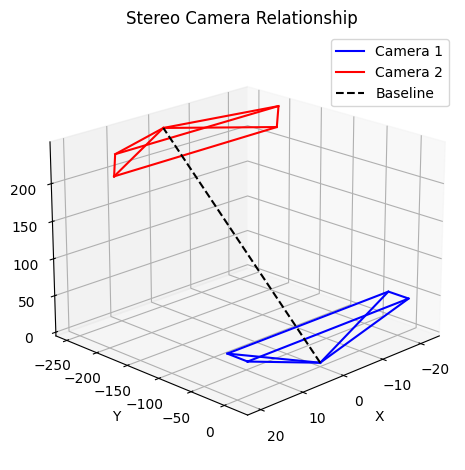

Stereo calibration complete. Parameters saved to ./calibration_results/stereo_params.pickle


In [74]:
calibrate_from_imgs(files1, files2, )